In [10]:
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv("churn_df_copy.csv")

In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Contract_encoded"] = le.fit_transform(df["Contract"])

In [3]:
df[["Contract","Contract_encoded"]].drop_duplicates()

,Contract,Contract_encoded
0,Month-to-month,0
1,One year,1
11,Two year,2


In [4]:
X = df[
[
"tenure",
"MonthlyCharges",
"Contract_encoded"
]
]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [14]:
X_scaled

array([[-1.27744458, -1.16032292, -0.8282069 ],
       [ 0.06632742, -0.25962894,  0.37127103],
       [-1.23672422, -0.36266036, -0.8282069 ],
       ...,
       [-0.87024095, -1.1686319 , -0.8282069 ],
       [-1.15528349,  0.32033821, -0.8282069 ],
       [ 1.36937906,  1.35896134,  1.57074896]], shape=(7043, 3))

In [6]:
from sklearn.cluster import KMeans

wcss=[]

for k in range(1,11):

    model=KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

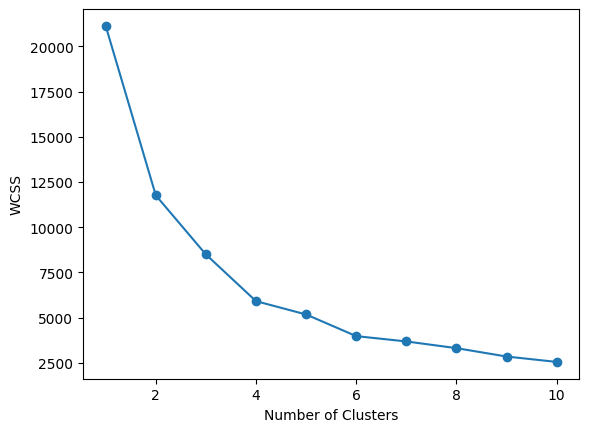

In [16]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
kmeans=KMeans(
n_clusters=3,
random_state=42
)

clusters=kmeans.fit_predict(X_scaled)

df["Cluster"]=clusters

In [17]:
kmeans.cluster_centers_

array([[ 1.10284418,  0.16813116,  1.16148503],
       [-0.39958191,  0.64265275, -0.73731035],
       [-0.73921446, -1.04985987, -0.35696223]])

In [18]:
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [19]:
df.groupby("Cluster")[
    ["tenure", "MonthlyCharges"]
].mean()

,tenure,MonthlyCharges
Cluster,,
0,59.498065,69.879140
1,22.551391,84.075473
2,14.276322,33.150865


In [21]:
pd.crosstab(
    df["Cluster"],
    df["Contract"]
)

Contract,Month-to-month,One year,Two year
Cluster,,,
0,3,785,1537
1,2490,205,0
2,1382,483,158


In [22]:
pd.crosstab(
    df["Cluster"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Cluster,,
0,93.419355,6.580645
1,53.172542,46.827458
2,77.558082,22.441918


In [23]:
df.groupby("Cluster")[["tenure", "MonthlyCharges"]].mean()

,tenure,MonthlyCharges
Cluster,,
0,59.498065,69.879140
1,22.551391,84.075473
2,14.276322,33.150865


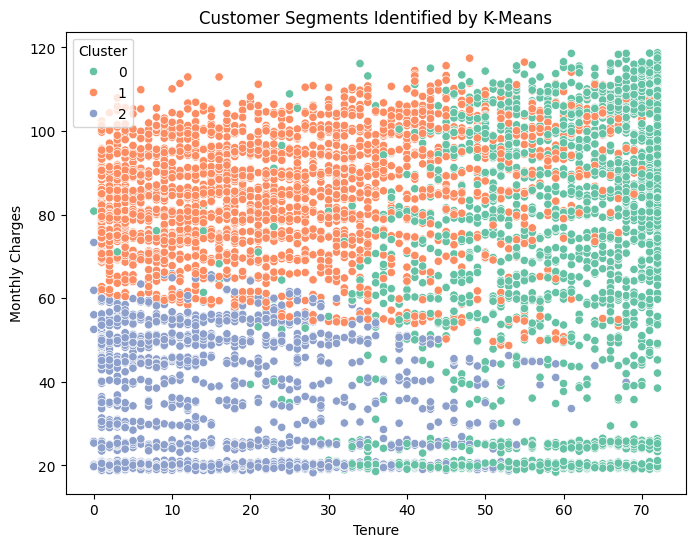

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Cluster",
    palette="Set2"
)
plt.title("Customer Segments Identified by K-Means")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()